In [13]:
import pandas as pd
import os

In [40]:
def extract_ip_addresses_from_dns_info(info_str):
    words = info_str.split(' ')
    ips = []
    
    for w in words:
        if len(w.split('.')) == 4:
            ips.append(w)
    return ips

In [134]:
def get_open_website_ips(df, website_name):
    dns_packets = df[df["Protocol"] == "DNS"].iterrows()
    open_router_ips = []
    
    for row in dns_packets:
        info_str = row[1]["Info"]
        if ("Standard query response" in info_str) and (website_name in info_str):
            new_open_router_ips = extract_ip_addresses_from_dns_info(info_str)
            open_router_ips.extend(new_open_router_ips)          
    return open_router_ips

In [135]:
df = pd.read_csv("pcaps/test0.csv")

open_router_ips = get_open_website_ips(df, "openrouter.ai")
zephaniah_dev_ips = get_open_website_ips(df, "zephaniahdev.com")

In [136]:
# dns_packets = df[df["Protocol"] == "DNS"]
# dns_packets.iloc[6]['Info']

# "openrouter.ai", "zephaniahdev.com"

In [137]:
def get_website_mask(df, ips_list):

    mask = None
    for ip in ips_list:
        if mask is None:
            mask = (df['Source'] == ip) | (df['Destination'] == ip)
        else:
            mask = (current_mask) | ( (df['Source'] == ip) | (df['Destination'] == ip) )
    return mask

# only_open_router = df[get_open_router_mask(df)]
# only_zephaniah_dev = df[(df['Source'] == '46.202.197.140') | (df['Destination'] == '46.202.197.140')]

In [146]:
def split_df_into_api_segments(df, open_router_ips):
    
    # 2d array where each list corresponds to an api call and the contents of the list are the
    # idxs in the dataframe corresponding to that activity
    idxs = []
    current_segment = []

    for i, row in df.iterrows():
        info_str = row['Info']
        print(info_str)
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            print("here")
            idxs.append(current_segment)
            current_segment = []
        else:
            if len(current_segment) == 0:
                if row['Source'] not in open_router_ips and row['Destination'] not in open_router_ips:
                    continue
            current_segment.append(i)

    dfs = []
    for segment in idxs:
        dfs.append(df.iloc[segment])

    return dfs

In [147]:
segments = split_df_into_api_segments(df, open_router_ips)

63805  >  5223 [ACK] Seq=1 Ack=1 Win=2048 Len=1370 TSval=728999622 TSecr=3092491363 [TCP PDU reassembled in 3]
63805  >  5223 [ACK] Seq=1371 Ack=1 Win=2048 Len=1370 TSval=728999622 TSecr=3092491363 [TCP PDU reassembled in 3]
Application Data
[TCP Retransmission] 63805  >  5223 [PSH, ACK] Seq=2237 Ack=1 Win=2048 Len=1370 TSval=728999825 TSecr=3092491363 [TCP PDU reassembled in 3]
5223  >  63805 [ACK] Seq=1 Ack=2741 Win=3115 Len=0 TSval=3092963110 TSecr=728999622
5223  >  63805 [ACK] Seq=1 Ack=3607 Win=3109 Len=0 TSval=3092963110 TSecr=728999622
[TCP Dup ACK 6#1] 5223  >  63805 [ACK] Seq=1 Ack=3607 Win=3127 Len=0 TSval=3092963229 TSecr=728999825 SLE=2237 SRE=3607
62795  >  443 Len=41
443  >  62795 Len=31
Membership Query, specific for group 224.0.0.251
Membership Query, specific for group 224.0.0.251
Membership Report group 224.0.0.251
Membership Query, specific for group 224.0.0.251
Application Data
57358  >  443 [ACK] Seq=1 Ack=40 Win=43 Len=0 TSval=2603805662 TSecr=4160906075
Applicat

In [148]:
only_open_router = segments[0][get_website_mask(segments[0], open_router_ips)]
only_zephaniah_dev = segments[0][get_website_mask(segments[0], zephaniah_dev_ips)]

/var/folders/tz/tjkc1y6s6z13lfjrq0gcrjnr0000gn/T/ipykernel_66751/599110928.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  only_open_router = segments[0][get_website_mask(segments[0], open_router_ips)]


In [149]:
only_zephaniah_dev

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column


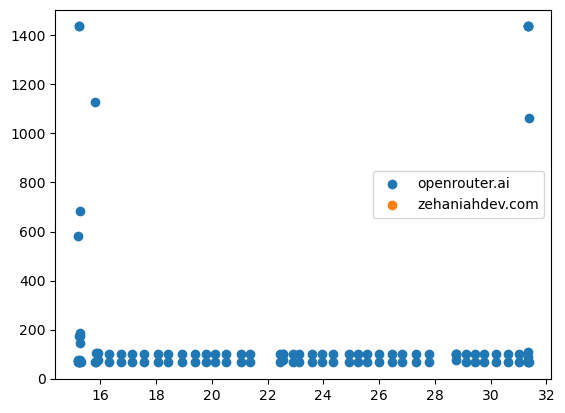

In [150]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

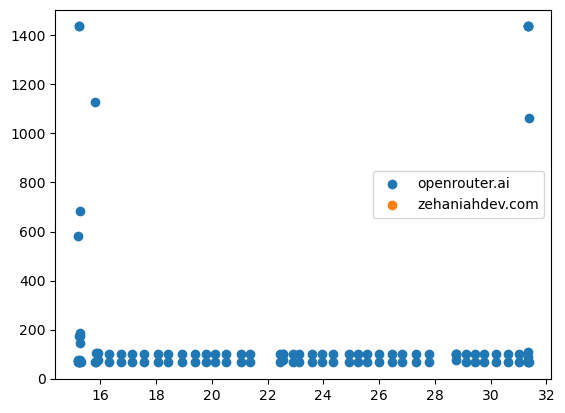

In [142]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [96]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,15.196938,10.150.14.95,104.18.3.115,TCP,78,57361 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57361.0,57361.0,23
23,24,15.208490,104.18.3.115,10.150.14.95,TCP,74,"443 > 57361 [SYN, ACK] Seq=0 Ack=1 Win=65535...",57361.0,57361.0,443.0,443.0,24
24,25,15.208649,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57361.0,57361.0,25
25,26,15.209370,10.150.14.95,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,57361.0,57361.0,26
26,27,15.252591,104.18.3.115,10.150.14.95,TCP,66,443 > 57361 [ACK] Seq=1 Ack=518 Win=131072 L...,57361.0,57361.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,31.361033,104.18.3.115,10.150.14.95,TLSv1.3,1064,"Application Data, Application Data, Applicatio...",57361.0,57361.0,443.0,443.0,154
154,155,31.361375,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1336 Ack=10382 Win=131...,443.0,443.0,57361.0,57361.0,155
209,210,54.055280,10.150.14.95,104.18.3.115,TCP,66,"57361 > 443 [FIN, ACK] Seq=1336 Ack=10382 Wi...",443.0,443.0,57361.0,57361.0,210
213,214,54.229522,104.18.3.115,10.150.14.95,TCP,66,"443 > 57361 [FIN, ACK] Seq=10382 Ack=1337 Wi...",57361.0,57361.0,443.0,443.0,214


In [97]:
only_zephaniah_dev

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
164,165,43.620507,10.150.14.95,46.202.197.140,TCP,78,57363 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57363.0,57363.0,165
166,167,43.741637,46.202.197.140,10.150.14.95,TCP,74,"443 > 57363 [SYN, ACK] Seq=0 Ack=1 Win=31856...",57363.0,57363.0,443.0,443.0,167
167,168,43.741828,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57363.0,57363.0,168
168,169,43.777993,10.150.14.95,46.202.197.140,TLSv1.3,583,Client Hello (SNI=zephaniahdev.com),443.0,443.0,57363.0,57363.0,169
169,170,43.896586,46.202.197.140,10.150.14.95,TCP,66,443 > 57363 [ACK] Seq=1 Ack=518 Win=31872 Le...,57363.0,57363.0,443.0,443.0,170
170,171,43.902648,46.202.197.140,10.150.14.95,TLSv1.3,1436,"Server Hello, Change Cipher Spec",57363.0,57363.0,443.0,443.0,171
171,172,43.902651,46.202.197.140,10.150.14.95,TCP,941,[TCP Previous segment not captured] 443 > 57...,57363.0,57363.0,443.0,443.0,172
172,173,43.902652,46.202.197.140,10.150.14.95,TLSv1.3,1436,"[TCP Retransmission] , Application Data",57363.0,57363.0,443.0,443.0,173
173,174,43.902749,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=518 Ack=1371 Win=13011...,443.0,443.0,57363.0,57363.0,174
174,175,43.902819,10.150.14.95,46.202.197.140,TCP,78,[TCP Dup ACK 174#1] 57363 > 443 [ACK] Seq=51...,443.0,443.0,57363.0,57363.0,175


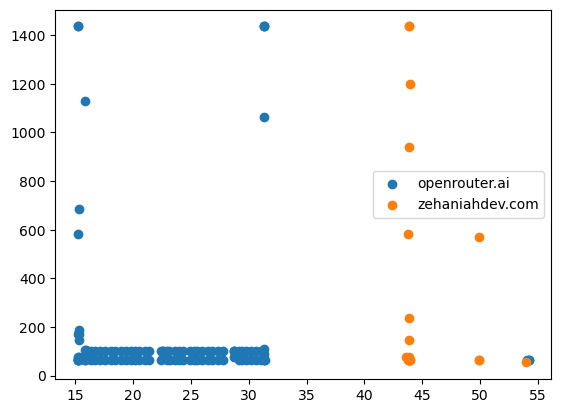

In [98]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [55]:
df['Source']

0        10.150.14.95
1        10.150.14.95
2        10.150.14.95
3        10.150.14.95
4       17.57.144.135
            ...      
232    17.248.168.168
233    17.248.168.168
234        10.150.0.2
235        10.150.0.2
236      10.150.14.95
Name: Source, Length: 237, dtype: object

In [51]:
(df['Source'] == '104.18.2.115') | (df['Destination'] == '104.18.2.115')

0      False
1      False
2      False
3      False
4      False
       ...  
232    False
233    False
234    False
235    False
236    False
Length: 237, dtype: bool